# Part 2: CNN Computer Vision – Manufacturing Defect Classification

**Repository Structure:**
```
part-2-cnn-computer-vision/
│
├── README.md
├── notebook.ipynb
├── requirements.txt
├── sample_predictions/
│   └── prediction_outputs.png
└── results/
    ├── accuracy_loss_curves.png
    └── confusion_matrix.png
```

**Dataset Source:** [Google Drive – Synthetic Manufacturing Defect Image Dataset](https://drive.google.com/drive/folders/18zfhUgV6QxMgmPeD9UupKepfY9zrL7Z2?usp=drive_link)

**Classes:** `normal` | `scratch` | `dent` | `stain`

**Total Images:** 480 (120 per class)

## 1. Install & Import Libraries

In [1]:
# Uncomment if running for the first time
# !pip install tensorflow matplotlib scikit-learn seaborn pandas numpy pillow

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully.")

TensorFlow version: 2.21.0
All libraries imported successfully.


## 2. Configuration & Dataset Setup

> **Dataset:** Download the images from the Google Drive link below and place them in the `images/` folder next to this notebook.
>
> 🔗 https://drive.google.com/drive/folders/18zfhUgV6QxMgmPeD9UupKepfY9zrL7Z2?usp=drive_link
>
> Expected structure after download:
> ```
> images/
>   normal/     (120 images)
>   scratch/    (120 images)
>   dent/       (120 images)
>   stain/      (120 images)
> labels.csv
> ```

In [3]:
# ─── Configuration ───────────────────────────────────────────────────────────
IMAGE_DIR   = 'images'          # Root folder containing class sub-folders
LABELS_CSV  = 'labels.csv'      # CSV with filename,class columns
IMG_SIZE    = (64, 64)          # Resize all images to this shape
BATCH_SIZE  = 32
EPOCHS      = 30
CLASSES     = ['normal', 'scratch', 'dent', 'stain']
NUM_CLASSES = len(CLASSES)

# Output folders
os.makedirs('results', exist_ok=True)
os.makedirs('sample_predictions', exist_ok=True)

print(f"Image size  : {IMG_SIZE}")
print(f"Batch size  : {BATCH_SIZE}")
print(f"Epochs      : {EPOCHS}")
print(f"Classes     : {CLASSES}")

Image size  : (64, 64)
Batch size  : 32
Epochs      : 30
Classes     : ['normal', 'scratch', 'dent', 'stain']


## 3. Load & Explore the Dataset

In [5]:
# Load labels.csv
if not os.path.exists(LABELS_CSV):
    raise FileNotFoundError(
        f"Could not find '{LABELS_CSV}'.\n"
        "Please download the dataset and place 'labels.csv' in the notebook directory, "
        "or update the LABELS_CSV variable with the correct path."
    )

import os

if not os.path.isdir(IMAGE_DIR):
    raise FileNotFoundError(
        f"Could not find image directory '{IMAGE_DIR}'.\n"
        "Please download the dataset images and place them under the 'images/' folder."
    )

df = pd.read_csv(LABELS_CSV)
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nClass distribution:")
print(df['class'].value_counts())

Shape: (480, 2)

First 5 rows:


,filename,class
0,images/normal/normal_001.png,normal
1,images/normal/normal_002.png,normal
2,images/normal/normal_003.png,normal
3,images/normal/normal_004.png,normal
4,images/normal/normal_005.png,normal



Class distribution:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


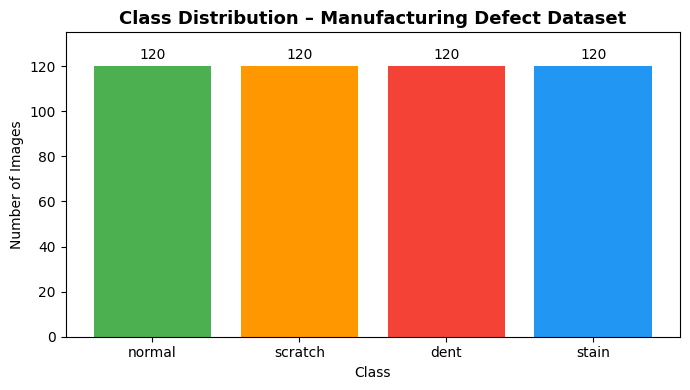

In [6]:
# Plot class distribution
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['class'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#4CAF50', '#FF9800', '#F44336', '#2196F3'])
ax.bar_label(bars, padding=3)
ax.set_title('Class Distribution – Manufacturing Defect Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.set_ylim(0, counts.max() + 15)
plt.tight_layout()
plt.show()

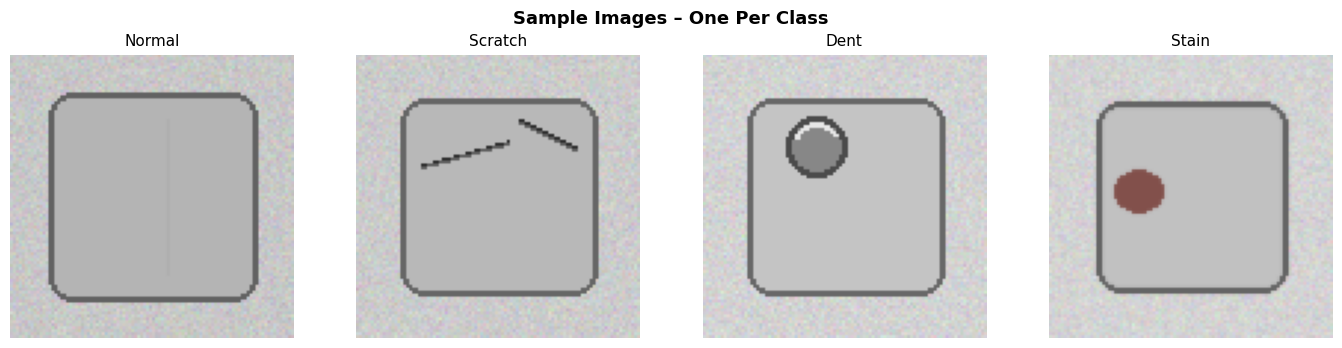

In [7]:
# Display sample images from each class
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 3.5))
fig.suptitle('Sample Images – One Per Class', fontsize=13, fontweight='bold')

for ax, cls in zip(axes, CLASSES):
    cls_files = df[df['class'] == cls]['filename'].values
    img_path = cls_files[0]  # Take the first sample
    try:
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'{cls}\n(image not found)', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(cls.capitalize(), fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Augmentation

In [8]:
def load_images_from_csv(df, img_size=IMG_SIZE):
    """Load all images listed in the CSV, resize, and normalise pixel values."""
    X, y = [], []
    class_to_idx = {cls: i for i, cls in enumerate(CLASSES)}
    missing = 0

    for _, row in df.iterrows():
        try:
            img = Image.open(row['filename']).convert('RGB').resize(img_size)
            X.append(np.array(img) / 255.0)   # Normalise to [0, 1]
            y.append(class_to_idx[row['class']])
        except FileNotFoundError:
            missing += 1

    if missing:
        print(f"Warning: {missing} image(s) not found and were skipped.")

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


X, y = load_images_from_csv(df)
print(f"X shape : {X.shape}   (samples, height, width, channels)")
print(f"y shape : {y.shape}")
print(f"Pixel range : [{X.min():.2f}, {X.max():.2f}]")

X shape : (480, 64, 64, 3)   (samples, height, width, channels)
y shape : (480,)
Pixel range : [0.13, 0.99]


In [9]:
# Train / Validation / Test split  (70% / 15% / 15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train      : {X_train.shape[0]} images")
print(f"Validation : {X_val.shape[0]} images")
print(f"Test       : {X_test.shape[0]} images")

Train      : 336 images
Validation : 72 images
Test       : 72 images


In [10]:
# Data augmentation for training set
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)

# Convert labels to one-hot for categorical cross-entropy
y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_cat   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

print("Data augmentation configured.")
print("One-hot encoding applied.")

Data augmentation configured.
One-hot encoding applied.


## 5. Build the CNN Model

In [11]:
def build_cnn(input_shape=(64, 64, 3), num_classes=4):
    """
    CNN Architecture:
    - 3 Convolutional blocks (Conv2D → BatchNorm → MaxPool → Dropout)
    - Fully connected head with Dropout
    - Softmax output for multi-class classification
    """
    model = models.Sequential([
        # ── Block 1 ──────────────────────────────────────────────────────────
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # ── Block 2 ──────────────────────────────────────────────────────────
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # ── Block 3 ──────────────────────────────────────────────────────────
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # ── Fully Connected Head ──────────────────────────────────────────────
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


model = build_cnn(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,604 (8.37 MB)

 Trainable params: 2,192,644 (8.36 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Train the Model

In [12]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True,
                  verbose=1),
    ModelCheckpoint('results/best_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val_cat),
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete.")

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4671 - loss: 1.7463 - val_accuracy: 0.2500 - val_loss: 1.4688
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.6250 - loss: 1.0186 - val_accuracy: 0.2500 - val_loss: 1.5357
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6382 - loss: 0.9691 - val_accuracy: 0.2500 - val_loss: 3.3950
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.5625 - loss: 0.9751 - val_accuracy: 0.2500 - val_loss: 3.6106
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7007 - loss: 0.7187 - val_accuracy: 0.2500 - val_loss: 6.0235
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.7812 - loss: 0.7101 - val_accuracy: 0.2500 - val_loss: 6.3207
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8158 - loss: 0.4829 - val_accuracy: 0.2500 - val_loss: 9.2892
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.8125 - loss: 0.4575 - val_accuracy: 0.2500 - val_l

## 7. Visualise Training Results

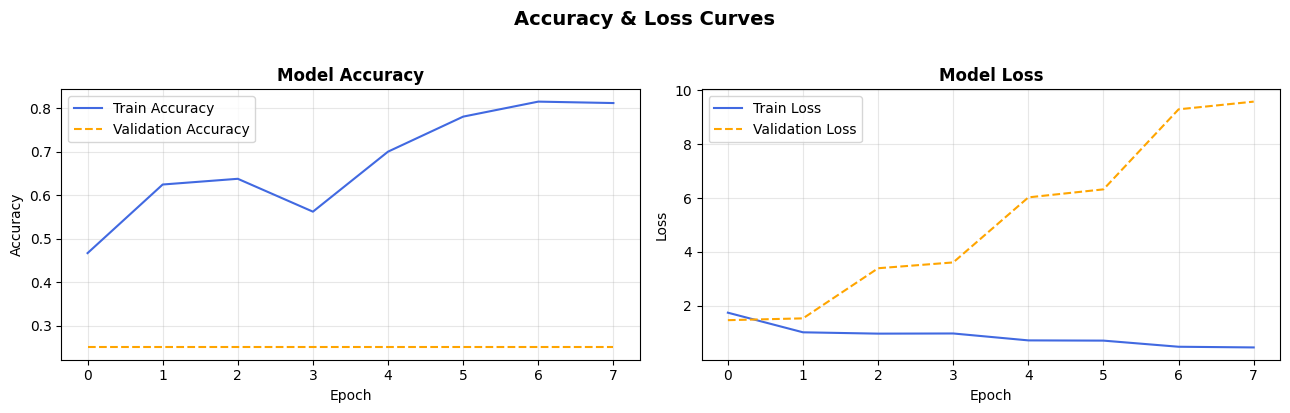

Saved → results/accuracy_loss_curves.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy',  color='orange', linestyle='--')
axes[0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss',      color='royalblue')
axes[1].plot(history.history['val_loss'], label='Validation Loss',  color='orange', linestyle='--')
axes[1].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Accuracy & Loss Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/accuracy_loss_curves.png")

## 8. Evaluate on Test Set

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")

Test Loss     : 1.4745
Test Accuracy : 0.2500  (25.00%)


In [15]:
# Predictions
y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=CLASSES))

Classification Report:

              precision    recall  f1-score   support

      normal       0.26      1.00      0.41        18
     scratch       0.00      0.00      0.00        18
        dent       0.00      0.00      0.00        18
       stain       0.00      0.00      0.00        18

    accuracy                           0.25        72
   macro avg       0.06      0.25      0.10        72
weighted avg       0.06      0.25      0.10        72



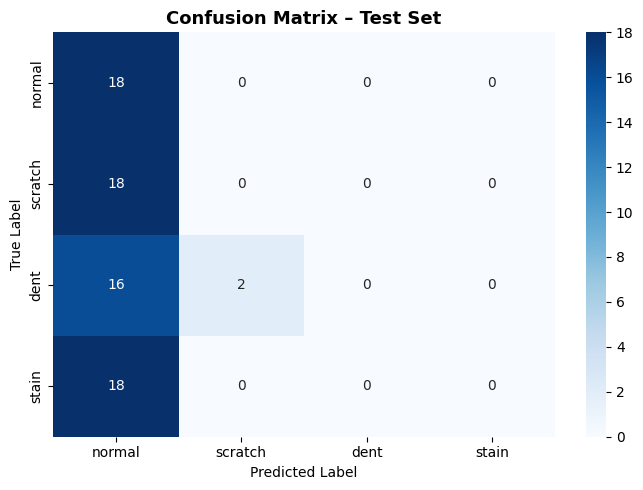

Saved → results/confusion_matrix.png


In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title('Confusion Matrix – Test Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/confusion_matrix.png")

## 9. Sample Predictions

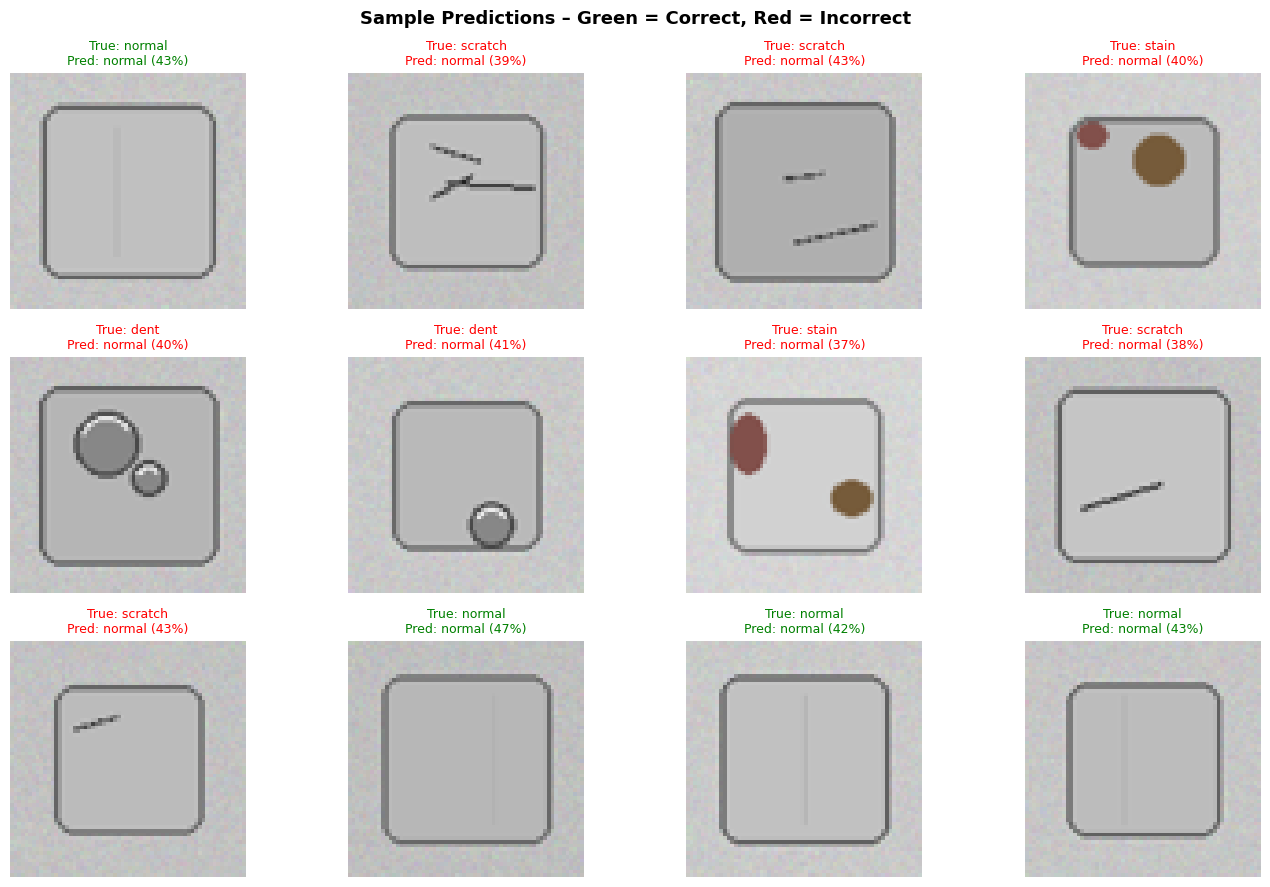

Saved → sample_predictions/prediction_outputs.png


In [17]:
# Display a grid of sample test images with predicted vs true labels
n_samples = 12
indices   = np.random.choice(len(X_test), n_samples, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
fig.suptitle('Sample Predictions – Green = Correct, Red = Incorrect',
             fontsize=13, fontweight='bold')

for i, (ax, idx) in enumerate(zip(axes.flat, indices)):
    img        = X_test[idx]
    true_label = CLASSES[y_test[idx]]
    pred_label = CLASSES[y_pred[idx]]
    confidence = y_pred_probs[idx][y_pred[idx]]
    correct    = true_label == pred_label

    ax.imshow(img)
    ax.set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.0%})",
        color='green' if correct else 'red',
        fontsize=9
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → sample_predictions/prediction_outputs.png")

## 10. Real-World Application – Manufacturing Quality Inspection

### How This Maps to Industry

| CNN Component | Manufacturing Analogy |
|---|---|
| Convolutional layers | Camera vision system scanning product surfaces |
| Pooling layers | Summarising key defect features regardless of position |
| Data augmentation | Simulating different lighting / camera angles on the line |
| Softmax output | Automated pass/fail decision with confidence score |

### Business Benefits
- **Speed:** CNN inspection runs in milliseconds vs. seconds for human visual checks.
- **Consistency:** No fatigue-related misses during long production shifts.
- **Traceability:** Each prediction is logged with a confidence score for quality audits.
- **Scalability:** The same model can be deployed across multiple production lines.

### Limitations & Next Steps
- The dataset is **synthetic** — real-world deployment requires images captured under actual production conditions.
- **Transfer learning** (e.g., MobileNetV2, EfficientNet) could boost accuracy further with the same data.
- Consider adding a **rejection threshold**: images below a confidence threshold are flagged for human review.

## 11. Save & Export the Final Model

In [18]:
# Save the final model
model.save('results/cnn_defect_classifier.keras')
print("Model saved → results/cnn_defect_classifier.keras")

# Summary of outputs produced
print("\n─── Outputs Generated ─────────────────────────────────────────")
print("  results/accuracy_loss_curves.png")
print("  results/confusion_matrix.png")
print("  results/best_model.keras")
print("  results/cnn_defect_classifier.keras")
print("  sample_predictions/prediction_outputs.png")
print("────────────────────────────────────────────────────────────────")

Model saved → results/cnn_defect_classifier.keras

─── Outputs Generated ─────────────────────────────────────────
  results/accuracy_loss_curves.png
  results/confusion_matrix.png
  results/best_model.keras
  results/cnn_defect_classifier.keras
  sample_predictions/prediction_outputs.png
────────────────────────────────────────────────────────────────
